In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, skew, kurtosis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [2]:
sns.set(style="whitegrid")

In [3]:
# 1️⃣ LOAD DATASET
print("\n📥 Loading Dataset...")
df = pd.read_csv("diabetes_dataset.csv")

print("📌 Initial Shape:", df.shape)
print("\n📋 Dataset Info:")
print(df.info())



📥 Loading Dataset...
📌 Initial Shape: (100000, 16)

📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-nul

In [4]:
print("\n📊 Statistical Summary:")
print(df.describe())


📊 Statistical Summary:
                year            age  race:AfricanAmerican     race:Asian  \
count  100000.000000  100000.000000         100000.000000  100000.000000   
mean     2018.360820      41.885856              0.202230       0.200150   
std         1.345239      22.516840              0.401665       0.400114   
min      2015.000000       0.080000              0.000000       0.000000   
25%      2019.000000      24.000000              0.000000       0.000000   
50%      2019.000000      43.000000              0.000000       0.000000   
75%      2019.000000      60.000000              0.000000       0.000000   
max      2022.000000      80.000000              1.000000       1.000000   

       race:Caucasian  race:Hispanic     race:Other  hypertension  \
count   100000.000000   100000.00000  100000.000000  100000.00000   
mean         0.198760        0.19888       0.199980       0.07485   
std          0.399069        0.39916       0.399987       0.26315   
min          0.

In [5]:
columns_to_drop = [
    'year', 'location',
    'race:AfricanAmerican','race:Asian','race:Caucasian','race:Hispanic','race:Other'
]
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')  # safe drop
print("\n✅ Columns after dropping unwanted ones:", df.columns)


✅ Columns after dropping unwanted ones: Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')


In [6]:
# 2️⃣ NULL & DUPLICATE CHECK
df.columns[df.isna().any()]
print("\n🔍 Missing Values:")
print(df.isnull().sum())



🔍 Missing Values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
hbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [7]:
# Numeric columns → fill with median
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns → fill with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if col != 'diabetes':  # target
        df[col] = df[col].fillna(df[col].mode()[0])

In [8]:

# Drop duplicates
df.drop_duplicates(inplace=True)
print("✅ Missing values and duplicates cleaned:")
print(df.isnull().sum())

✅ Missing values and duplicates cleaned:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
hbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [9]:
# 4️⃣ OUTLIER REMOVAL
numeric_columns = ['age','bmi','hbA1c_level','blood_glucose_level']
z_scores = np.abs(zscore(df[numeric_columns]))
df = df[(z_scores < 3).all(axis=1)]
print("✅ Shape after outlier removal:", df.shape)

✅ Shape after outlier removal: (92542, 9)



🔹 age distribution:
Skewness: -0.032
Kurtosis: -1.01


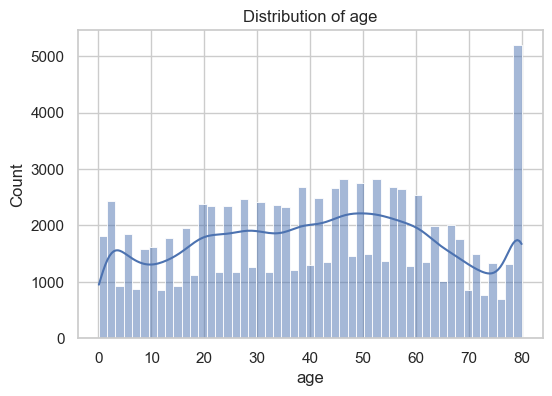


🔹 bmi distribution:
Skewness: 0.429
Kurtosis: 0.683


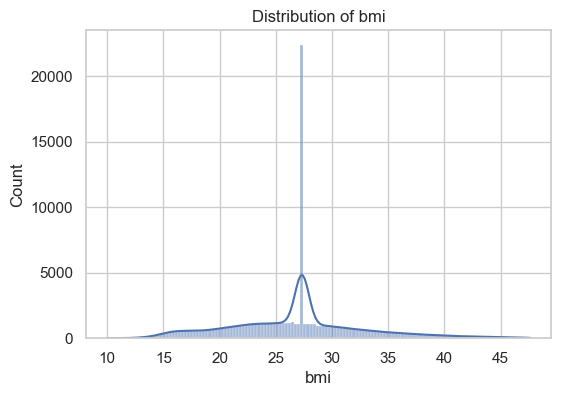


🔹 hbA1c_level distribution:
Skewness: -0.464
Kurtosis: -0.62


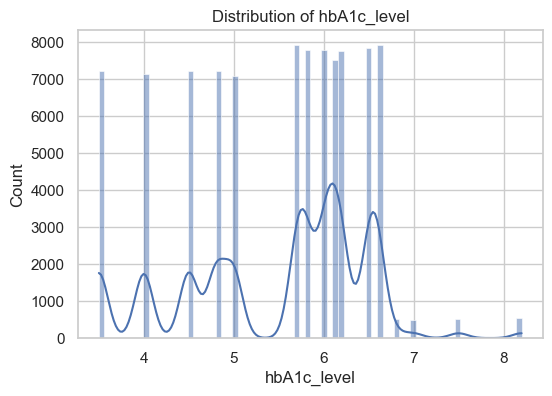


🔹 blood_glucose_level distribution:
Skewness: 0.275
Kurtosis: 0.008


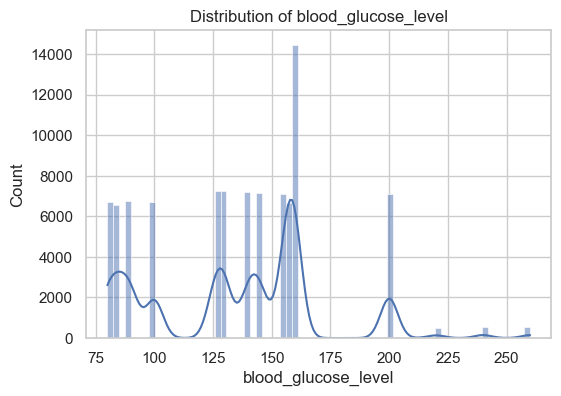

In [10]:
#5️⃣ DISTRIBUTION ANALYSIS (Optional)
for col in numeric_columns:
    print(f"\n🔹 {col} distribution:")
    print("Skewness:", round(skew(df[col]),3))
    print("Kurtosis:", round(kurtosis(df[col]),3))
    
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()



In [11]:
# 6️⃣ FEATURE ENGINEERING

# BMI Category
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df['bmi_category'] = df['bmi'].apply(bmi_category)
# Age Group
df['age_group'] = pd.cut(df['age'], bins=[0,30,45,60,100], labels=['Young','Adult','Senior','Elder'])

# Interaction Feature
df['bmi_glucose_interaction'] = df['bmi'] * df['blood_glucose_level']

print("🌟 Feature Engineering Preview:")
print(df[['bmi','bmi_category','age','age_group','bmi_glucose_interaction']].head())


🌟 Feature Engineering Preview:
     bmi bmi_category   age age_group  bmi_glucose_interaction
0  27.32   Overweight  32.0     Adult                  2732.00
1  19.95       Normal  29.0     Young                  1795.50
2  23.76       Normal  18.0     Young                  3801.60
3  27.32   Overweight  41.0     Adult                  4343.88
4  23.75       Normal  52.0    Senior                  2137.50


In [12]:
# Convert smoking_history to numeric codes
from sklearn.preprocessing import LabelEncoder

le_smoke = LabelEncoder()
df['smoking_history'] = le_smoke.fit_transform(df['smoking_history'])
print("\n✅ Encoded smoking_history preview:")
print(df[['smoking_history']].head())

# 1️⃣ Health Risk Score
df['health_risk_score'] = (
    df['bmi'] / df['bmi'].max() + 
    df['blood_glucose_level'] / df['blood_glucose_level'].max() +
    df['hbA1c_level'] / df['hbA1c_level'].max() +
    df['hypertension'] + 
    df['heart_disease']
)
print("\n🌟 Health Risk Score Preview:")
print(df[['bmi','blood_glucose_level','hbA1c_level','hypertension','heart_disease','health_risk_score']].head())

# 2️⃣ Glucose/HbA1c Ratio
df['glucose_hba1c_ratio'] = df['blood_glucose_level'] / (df['hbA1c_level'] + 1)
print("\n🌟 Glucose/HbA1c Ratio Preview:")
print(df[['blood_glucose_level','hbA1c_level','glucose_hba1c_ratio']].head())

# 3️⃣ BMI/Age Ratio
df['bmi_age_ratio'] = df['bmi'] / (df['age'] + 1)
print("\n🌟 BMI/Age Ratio Preview:")
print(df[['bmi','age','bmi_age_ratio']].head())

# 4️⃣ Smoking × Age Interaction
df['smoking_age_interaction'] = df['smoking_history'] * df['age']
print("\n🌟 Smoking × Age Interaction Preview:")
print(df[['smoking_history','age','smoking_age_interaction']].head())

# 5️⃣ Hypertension × Heart Disease
df['bp_heart_interaction'] = df['hypertension'] * df['heart_disease']
print("\n🌟 Hypertension × Heart Disease Interaction Preview:")
print(df[['hypertension','heart_disease','bp_heart_interaction']].head())

# 6️⃣ High-risk flags
df['high_bmi_flag'] = df['bmi'].apply(lambda x: 1 if x >= 30 else 0)
df['high_glucose_flag'] = df['blood_glucose_level'].apply(lambda x: 1 if x >= 140 else 0)
df['high_hba1c_flag'] = df['hbA1c_level'].apply(lambda x: 1 if x >= 6.5 else 0)
print("\n🌟 High-risk Flags Preview:")
print(df[['bmi','high_bmi_flag','blood_glucose_level','high_glucose_flag','hbA1c_level','high_hba1c_flag']].head())





✅ Encoded smoking_history preview:
   smoking_history
0                4
1                4
2                4
3                4
4                4

🌟 Health Risk Score Preview:
     bmi  blood_glucose_level  hbA1c_level  hypertension  heart_disease  \
0  27.32                  100          5.0             0              0   
1  19.95                   90          5.0             0              0   
2  23.76                  160          4.8             0              0   
3  27.32                  159          4.0             0              0   
4  23.75                   90          6.5             0              0   

   health_risk_score  
0           1.568080  
1           1.374852  
2           1.699700  
3           1.673052  
4           1.637577  

🌟 Glucose/HbA1c Ratio Preview:
   blood_glucose_level  hbA1c_level  glucose_hba1c_ratio
0                  100          5.0            16.666667
1                   90          5.0            15.000000
2                  160      

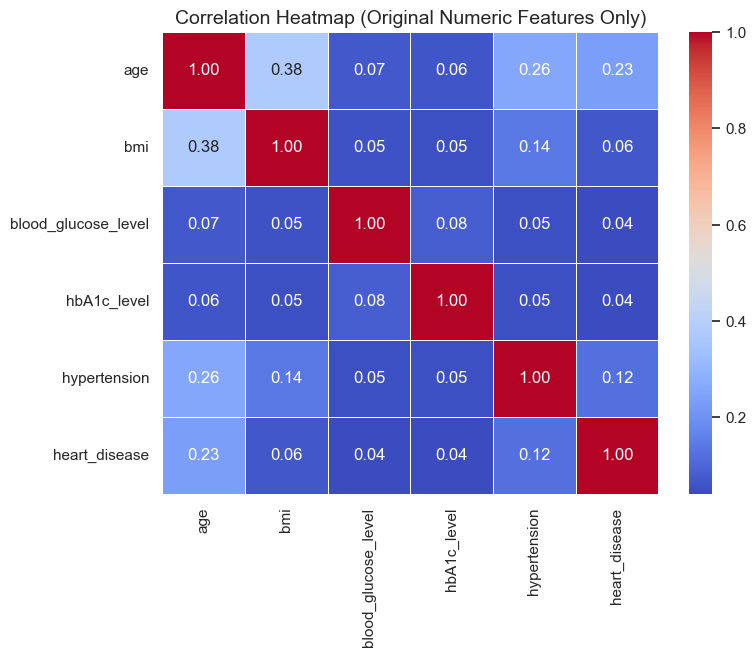

In [13]:
# 🔹 CORRELATION HEATMAP (ONLY ORIGINAL NUMERIC FEATURES)
numeric_features = ['age', 'bmi', 'blood_glucose_level', 'hbA1c_level', 'hypertension', 'heart_disease']

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap (Original Numeric Features Only)", fontsize=14)
plt.show()


In [14]:
print("\n✅ Feature Preview:")
print(df.head())



✅ Feature Preview:
   gender   age  hypertension  heart_disease  smoking_history    bmi  \
0  Female  32.0             0              0                4  27.32   
1  Female  29.0             0              0                4  19.95   
2    Male  18.0             0              0                4  23.76   
3    Male  41.0             0              0                4  27.32   
4  Female  52.0             0              0                4  23.75   

   hbA1c_level  blood_glucose_level  diabetes bmi_category age_group  \
0          5.0                  100         0   Overweight     Adult   
1          5.0                   90         0       Normal     Young   
2          4.8                  160         0       Normal     Young   
3          4.0                  159         0   Overweight     Adult   
4          6.5                   90         0       Normal    Senior   

   bmi_glucose_interaction  health_risk_score  glucose_hba1c_ratio  \
0                  2732.00           1.56808

In [15]:
from sklearn.preprocessing import LabelEncoder

# List of categorical/string columns to encode
cat_cols = ['bmi_category','age_group','gender', 'smoking_history']  # add any other string columns here

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f"\n✅ {col} encoded:")
    print(df[[col]].head())


✅ bmi_category encoded:
   bmi_category
0             2
1             0
2             0
3             2
4             0

✅ age_group encoded:
   age_group
0          0
1          3
2          3
3          0
4          2

✅ gender encoded:
   gender
0       0
1       0
2       1
3       1
4       0

✅ smoking_history encoded:
   smoking_history
0                4
1                4
2                4
3                4
4                4


In [18]:
# X = features, y = target
X = df.drop('diabetes', axis=1) 
y = df['diabetes']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


📌 Random Forest Accuracy: 0.9693
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17360
           1       0.91      0.56      0.69      1149

    accuracy                           0.97     18509
   macro avg       0.94      0.78      0.84     18509
weighted avg       0.97      0.97      0.97     18509


📌 Decision Tree Accuracy: 0.9499
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     17360
           1       0.59      0.64      0.61      1149

    accuracy                           0.95     18509
   macro avg       0.78      0.80      0.79     18509
weighted avg       0.95      0.95      0.95     18509


📌 KNN Accuracy: 0.9581
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17360
           1       0.78      0.46      0.58      1149

    accuracy                           0.96     18509
   macro avg       0.87      0.72   

C:\Users\LENOVO\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


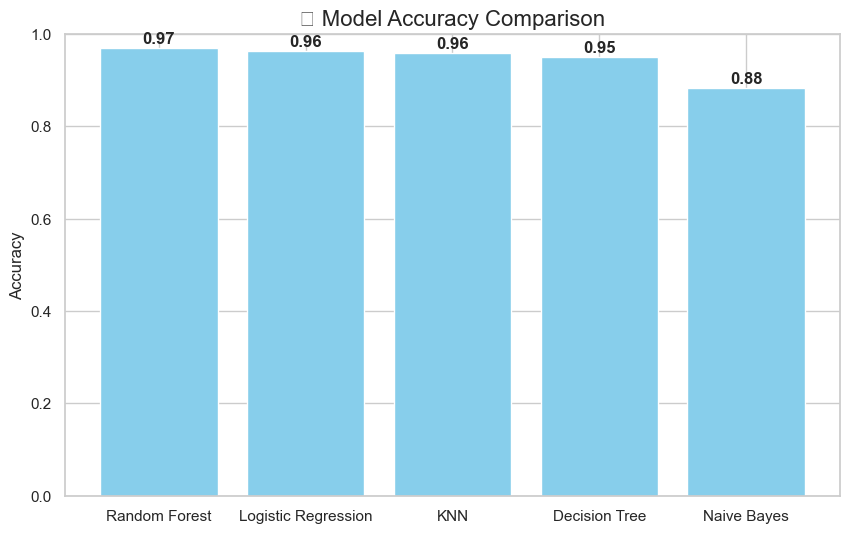

In [19]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Naive Bayes": GaussianNB()
}

results = []
scaler_model = StandardScaler()
X_train_scaled = scaler_model.fit_transform(X_train)
X_test_scaled = scaler_model.transform(X_test)

for name, model in models.items():
    if name in ["KNN", "Logistic Regression"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"\n📌 {name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    results.append((name, acc))
# 8️⃣ MODEL COMPARISON
results_df = pd.DataFrame(results, columns=['Model','Accuracy']).sort_values(by='Accuracy', ascending=False)
print("\n✅ Model Comparison Table:\n", results_df)
# 7️⃣ Plot Model Accuracy Comparison
plt.figure(figsize=(10,6))
plt.bar(results_df['Model'], results_df['Accuracy'], color='skyblue')
plt.title("📊 Model Accuracy Comparison", fontsize=16)
plt.ylabel("Accuracy")
plt.ylim(0,1)
for i, v in enumerate(results_df['Accuracy']):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

In [20]:
# 🌟 Interactive Diabetes Prediction & Recommendation

# ✅ Define best_model and selected_features
best_model = models["Random Forest"]  # Best model from comparison
selected_features = list(X_train.columns)  # Use exact training feature order

def interactive_diabetes_predictor():
    print("🩺 Welcome to the Interactive Diabetes Predictor! 🩺\n")

    # ---------------- Input Patient Info ----------------
    age = float(input("👶 Enter Age (years): "))
    bmi = float(input("⚖️ Enter BMI: "))
    blood_glucose_level = float(input("🩸 Enter Blood Glucose Level (mg/dL): "))
    hbA1c_level = float(input("🧪 Enter HbA1c Level (%): "))
    hypertension = int(input("💓 Hypertension? (Yes=1 / No=0): "))
    heart_disease = int(input("❤️ Heart Disease? (Yes=1 / No=0): "))

    # ---------------- Smoking History ----------------
    print("🚬 Smoking History Options: 1=Never, 2=Former, 3=Current")
    smoking_input = int(input("Select Smoking History (1/2/3): "))
    smoking_map = {1: 0, 2: 1, 3: 2}
    smoking_numeric = smoking_map.get(smoking_input, 0)

    # ---------------- Gender ----------------
    print("👤 Gender Options: 1=Male, 2=Female")
    gender_input = int(input("Select Gender (1/2): "))
    gender_map = {1: 1, 2: 0}  # Male=1, Female=0
    gender_numeric = gender_map.get(gender_input, 1)

    # ---------------- Create Input DataFrame ----------------
    df_input = pd.DataFrame([{
        'gender': gender_numeric,
        'age': age,
        'hypertension': hypertension,
        'heart_disease': heart_disease,
        'smoking_history': smoking_numeric,
        'bmi': bmi,
        'hbA1c_level': hbA1c_level,
        'blood_glucose_level': blood_glucose_level
    }])
    
    # ✅ BMI Category (numeric to match training)
    def bmi_category(bmi):
        if bmi < 18.5:
            return 0  # Underweight
        elif bmi < 25:
            return 1  # Normal
        elif bmi < 30:
            return 2  # Overweight
        else:
            return 3  # Obese

    df_input['bmi_category'] = df_input['bmi'].apply(bmi_category)

    # ✅ Age Group (numeric to match training)
    df_input['age_group'] = pd.cut(
        df_input['age'],
        bins=[0, 30, 45, 60, 100],
        labels=[0, 1, 2, 3]
    ).astype(int)

    # ✅ BMI × Glucose Interaction
    df_input['bmi_glucose_interaction'] = df_input['bmi'] * df_input['blood_glucose_level']

    # Health Risk Score
    df_input['health_risk_score'] = (
        df_input['bmi'] / df['bmi'].max() +
        df_input['blood_glucose_level'] / df['blood_glucose_level'].max() +
        df_input['hbA1c_level'] / df['hbA1c_level'].max() +
        df_input['hypertension'] +
        df_input['heart_disease']
    )
    df_input['glucose_hba1c_ratio'] = df_input['blood_glucose_level'] / (df_input['hbA1c_level'] + 1)
    df_input['bmi_age_ratio'] = df_input['bmi'] / (df_input['age'] + 1)
    df_input['smoking_age_interaction'] = df_input['smoking_history'] * df_input['age']
    df_input['bp_heart_interaction'] = df_input['hypertension'] * df_input['heart_disease']
    df_input['high_bmi_flag'] = df_input['bmi'].apply(lambda x: 1 if x >= 30 else 0)
    df_input['high_glucose_flag'] = df_input['blood_glucose_level'].apply(lambda x: 1 if x >= 140 else 0)
    df_input['high_hba1c_flag'] = df_input['hbA1c_level'].apply(lambda x: 1 if x >= 6.5 else 0)

    # ---------------- Select Features in Correct Order ----------------
    X_new = df_input[selected_features]  # ✅ Matches training column order exactly

    # ---------------- Predict Diabetes Risk ----------------
    pred = best_model.predict(X_new)[0]  # ✅ Random Forest uses unscaled input

    # ---------------- Recommendations ----------------
    print("\n🔹 Diabetes Prediction & Recommendation 🔹\n")
    if pred == 0:
        print("🎉 Good news! You have a LOW risk of diabetes. 🟢")
        print("💡 Recommendation: Maintain a healthy lifestyle, balanced diet, and regular exercise. 🏃‍♂️🥗")
        print("⚖️ Ideal BMI: 18.5–24.9 | 🩸 Blood Glucose: 70–140 mg/dL | 🧪 HbA1c: <5.7%")
    else:
        print("🚨 Warning! You have a HIGH risk of diabetes. 🔴")
        print("💡 Recommendation: Consult your doctor immediately, follow prescribed medications, and manage diet & exercise strictly. 🏥🥦")
        print("⚖️ Aim for BMI: 18.5–24.9 | 🩸 Blood Glucose: 70–140 mg/dL | 🧪 HbA1c: <5.7%")

# ---------------- Run the Interactive Predictor ----------------
interactive_diabetes_predictor()

🩺 Welcome to the Interactive Diabetes Predictor! 🩺



👶 Enter Age (years):  21
⚖️ Enter BMI:  19
🩸 Enter Blood Glucose Level (mg/dL):  80
🧪 Enter HbA1c Level (%):  5.2
💓 Hypertension? (Yes=1 / No=0):  0
❤️ Heart Disease? (Yes=1 / No=0):  0


🚬 Smoking History Options: 1=Never, 2=Former, 3=Current


Select Smoking History (1/2/3):  1


👤 Gender Options: 1=Male, 2=Female


Select Gender (1/2):  2



🔹 Diabetes Prediction & Recommendation 🔹

🎉 Good news! You have a LOW risk of diabetes. 🟢
💡 Recommendation: Maintain a healthy lifestyle, balanced diet, and regular exercise. 🏃‍♂️🥗
⚖️ Ideal BMI: 18.5–24.9 | 🩸 Blood Glucose: 70–140 mg/dL | 🧪 HbA1c: <5.7%
